# Лабораторная работа №3

**Вариант 3.2**

**Выполнили:** Аверьянова Мария, Калягин Дмитрий, Кашникова Анна, Климович Анна

## Функция оптимизации

Рассмотрим задачу минимизации:

$$\begin{aligned}
\text{minimize} \quad & f(x) = \sum_{i=1}^n x_i \log x_i \\
\text{subject to} \quad & Ax = b \\
& x \geq \mathbf{1}
\end{aligned}$$

где $A \in \mathbb{R}^{p \times n}$, $b \in \mathbb{R}^p$, $p < n$.

---

## 1. Логарифмический барьер и исследование на выпуклость

### 1.1. Прямая задача с логарифмическим барьером

Неравенства: $g_i(x) = 1 - x_i \leq 0$ (так как $x_i \geq 1$)

Логарифмический барьер:
$$B_L(x) = -\sum_{i=1}^n \log(x_i - 1)$$

Барьерная задача для фиксированного $t > 0$:
$$\min_x \left\{ t\sum_{i=1}^n x_i \log x_i - \sum_{i=1}^n \log(x_i - 1) \right\}$$
$$\text{subject to } Ax = b$$

**Исследование на выпуклость:**

Функция $f(x) = \sum_{i=1}^n x_i \log x_i$ выпукла, так как:
- $\frac{d^2}{dx_i^2}(x_i \log x_i) = \frac{1}{x_i} > 0$ при $x_i > 0$

Барьерная функция $-\log(x_i - 1)$ выпукла при $x_i > 1$, так как:
- $\frac{d^2}{dx_i^2}[-\log(x_i - 1)] = \frac{1}{(x_i-1)^2} > 0$

**Вывод:** Барьерная задача выпукла (сумма выпуклых функций).

---

### 1.2. Двойственная задача с логарифмическим барьером

Запишем ограничения как $1-x_i\le 0$ и введём множители $\lambda_i\ge 0$:

$$L(x,\nu,\lambda)=\sum_{i=1}^n x_i\log x_i+\nu^T(Ax-b)+\lambda^T(\mathbf 1-x).$$

Условие минимума по $x$:

$$\log x_i+1+a_i^T\nu-\lambda_i=0,$$

откуда

$$x_i(\nu,\lambda)=\exp(-1-a_i^T\nu+\lambda_i).$$

Двойственная функция:

$$q(\nu,\lambda)=-b^T\nu+\mathbf 1^T\lambda-\sum_{i=1}^n \exp(-1-a_i^T\nu+\lambda_i).$$

Двойственная задача максимизации:

$$\max_{\nu,\lambda}\;q(\nu,\lambda),\qquad \lambda\ge 0.$$

Эквивалентная задача минимизации:

$$\min_{\nu,\lambda}\;\varphi(\nu,\lambda)=b^T\nu-\mathbf 1^T\lambda+\sum_{i=1}^n \exp(-1-a_i^T\nu+\lambda_i),\qquad \lambda\ge 0.$$

Барьерная задача для двойственной задачи:

$$\min_{\nu,\lambda}\;t\varphi(\nu,\lambda)-\sum_{i=1}^n\log\lambda_i,\qquad \lambda_i>0.$$

**Исследование на выпуклость:**

Функция $\varphi(\nu,\lambda)$ выпукла, потому что состоит из линейной части и суммы экспонент от аффинных функций. Барьер $-\sum_i\log\lambda_i$ выпуклый на $\lambda_i>0$. Поэтому двойственная барьерная задача выпукла.


## 2. Генерация тестовых примеров и эталонное решение через CVXPY

In [21]:
import time
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import pandas as pd
from pathlib import Path
from scipy.linalg import svd
from scipy.optimize import minimize
from typing import List, Dict, Tuple
from scipy.sparse.linalg import cg

In [22]:
def entropy_objective(x: np.ndarray) -> float:
    if np.any(x <= 0):
        return np.inf
    return np.sum(x * np.log(x))

def recover_primal_from_dual(nu: np.ndarray, lam: np.ndarray, A: np.ndarray) -> np.ndarray:
    # return np.exp(-A.T @ nu - 1)
    return np.exp(-1 - A.T @ nu + lam)

def generate_full_rank_matrix(p: int, n: int, rng) -> np.ndarray:
    while True:
        A = rng.standard_normal((p, n))
        if np.linalg.matrix_rank(A) == p:
            return A

def nullspace_basis(A: np.ndarray, tol=1e-12) -> np.ndarray:
    U, S, Vt = svd(A, full_matrices=True)
    rank = np.sum(S > tol * S[0])
    return Vt[rank:].T

ГЕНЕРАЦИЯ ЗАДАЧИ

In [23]:
def generate_test_problem(n: int, p: int, seed: int, margin: float = 0.5):
    rng = np.random.default_rng(seed)

    A = generate_full_rank_matrix(p, n, rng)

    # Генерация допустимой точки x >= 1
    x_feas = 1.0 + margin + np.abs(rng.standard_normal(n))  # x >= 1

    b = A @ x_feas
    N = nullspace_basis(A)

    return {
        'A': A,
        'b': b,
        'x_feas': x_feas,
        'N': N,
        'rng': rng,
        'n': n,
        'p': p
    }

СТАРТОВЫЕ ТОЧКИ

In [24]:
def generate_feasible_starts(x_ref, N, num_starts, rng, margin=1e-4):
    starts = []
    n_p = N.shape[1]

    if n_p == 0:
        return [x_ref.copy() for _ in range(num_starts)]

    for _ in range(num_starts):
        direction = N @ rng.standard_normal(n_p)

        if np.linalg.norm(direction) < 1e-14:
            starts.append(x_ref.copy())
            continue

        lower, upper = -np.inf, np.inf

        for xi, di in zip(x_ref, direction):
            if abs(di) < 1e-14:
                continue

            bound = (1.0 + margin - xi) / di

            if di > 0:
                lower = max(lower, bound)
            else:
                upper = min(upper, bound)

        if not np.isfinite(lower):
            lower = -1.0
        if not np.isfinite(upper):
            upper = 1.0

        if lower >= upper:
            starts.append(x_ref.copy())
            continue

        alpha = rng.uniform(0.5 * lower, 0.5 * upper)
        x0 = x_ref + alpha * direction

        if np.min(x0) <= 1.0:
            x0 = x_ref.copy()

        starts.append(x0)

    return starts

CVXPY РЕШЕНИЕ

In [25]:
def solve_primal_cvxpy(A, b):
    n = A.shape[1]
    x = cp.Variable(n)

    objective = cp.Minimize(cp.sum(-cp.entr(x)))
    constraints = [A @ x == b, x >= 1.0]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if x.value is None:
        raise RuntimeError("Primal solve failed")

    x_star = np.asarray(x.value).ravel()
    f_star = entropy_objective(x_star)

    return x_star, f_star


def solve_dual_cvxpy(A, b):
    p, n = A.shape
    nu = cp.Variable(p)
    lam = cp.Variable(n, nonneg=True)

    phi_expr = (
        b @ nu
        - cp.sum(lam)
        + cp.sum(
            cp.exp(-1 - A.T @ nu + lam)
        )
    )

    prob = cp.Problem(cp.Minimize(phi_expr))

    prob.solve(
        solver=cp.SCS,
        eps=1e-8,
        max_iters=10000
    )

    if nu.value is None or lam.value is None:
        raise RuntimeError("Dual solve failed")

    nu_star = np.asarray(nu.value).ravel()
    lam_star = np.asarray(lam.value).ravel()

    phi_star = float(prob.value)
    q_star = -phi_star

    return nu_star, lam_star, q_star, phi_star

In [26]:
def build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    base_seed=1000,
    save_path=None,
):
    problems: List[Dict] = []
    global_problem_id = 0


    for n in n_values:
        p = n // 2  # p < n

        print(f"\n>>> n = {n}, p = {p}")

        for inst_id in range(num_instances):
            seed = base_seed * n + inst_id

            prob = generate_test_problem(n, p, seed)
            A = prob["A"]
            b = prob["b"]
            N = prob["N"]
            rng = prob["rng"]

            # CVXPY reference solutions
            x_star, f_star = solve_primal_cvxpy(A, b)
            nu_star, lam_star, q_star, phi_star = solve_dual_cvxpy(A, b)

            x_dual = recover_primal_from_dual(nu_star, lam_star, A)
            duality_gap = abs(f_star - q_star)

            # primal feasible starts
            primal_starts = generate_feasible_starts(
                prob["x_feas"], N, num_starts, rng
            )

            # dual starts
            dual_starts = [
                rng.standard_normal(p) * 0.1
                for _ in range(num_starts)
            ]


            problems.append({
                "problem_id": global_problem_id,
                "n": n,
                "p": p,
                "instance_id": inst_id,
                "seed": seed,
                "A": A,
                "b": b,
                "N": N,
                "x_feas": prob["x_feas"],
                "x_star": x_star,
                "f_star": f_star,
                "nu_star": nu_star,
                "lam_star" : lam_star,
                "q_star": q_star,
                "phi_star": phi_star,
                "x_dual": x_dual,
                "duality_gap": duality_gap,
                "primal_starts": primal_starts,
                "dual_starts": dual_starts,
            })

            print(f"  Instance {inst_id}: f* = {f_star:.4f}, "
                  f"q* = {q_star:.4f}, gap = {duality_gap:.2e}")

            global_problem_id += 1

    if save_path is not None:
        with open(save_path, "wb") as f:
            pickle.dump(problems, f)
        print(f"\nDataset saved to {save_path}")

    return problems

In [27]:
problems = build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    save_path="entropy_problems.pkl",
)


>>> n = 10, p = 5
  Instance 0: f* = 12.1291, q* = 12.1291, gap = 2.17e-08
  Instance 1: f* = 6.8180, q* = 6.8180, gap = 1.04e-08
  Instance 2: f* = 16.1214, q* = 16.1214, gap = 1.57e-08
  Instance 3: f* = 10.2027, q* = 10.2027, gap = 2.25e-08
  Instance 4: f* = 14.8322, q* = 14.8322, gap = 1.63e-08

>>> n = 20, p = 10
  Instance 0: f* = 20.6607, q* = 20.6607, gap = 6.22e-08
  Instance 1: f* = 23.2151, q* = 23.2151, gap = 1.14e-07
  Instance 2: f* = 36.1472, q* = 36.1472, gap = 8.79e-08
  Instance 3: f* = 19.8717, q* = 19.8717, gap = 1.41e-08
  Instance 4: f* = 21.0615, q* = 21.0615, gap = 3.29e-07

>>> n = 30, p = 15
  Instance 0: f* = 33.5016, q* = 33.5016, gap = 1.67e-07
  Instance 1: f* = 48.4108, q* = 48.4108, gap = 5.59e-08
  Instance 2: f* = 28.4016, q* = 28.4016, gap = 3.05e-07
  Instance 3: f* = 39.1883, q* = 39.1883, gap = 5.96e-09
  Instance 4: f* = 22.8000, q* = 22.8000, gap = 4.73e-07

>>> n = 40, p = 20
  Instance 0: f* = 49.2144, q* = 49.2144, gap = 6.84e-07
  Instance 

## 3. Барьерный метод

In [28]:
def line_search_scalar(
    f,
    x,
    p,
    gamma=1.0,
    min_gamma=1e-8,
    num=30,
):
    f_x = f(x)

    if not np.isfinite(f_x):
        return 0.0

    gammas = np.geomspace(gamma, min_gamma, num)

    best_gamma = 0.0
    best_value = f_x

    for c_gamma in gammas:
        value = f(x + c_gamma * p)

        if np.isfinite(value) and value < best_value:
            best_value = value
            best_gamma = c_gamma

    return best_gamma

### 3.1 Барьерная задача - метод Ньютона 

In [29]:
def barrier_function_primal(x: np.ndarray, t: float) -> float:
    if np.any(x <= 1):
        return np.inf

    entropy_term = np.sum(x * np.log(x))
    barrier_term = np.sum(np.log(x - 1))

    return t * entropy_term - barrier_term

def barrier_gradient_primal(x: np.ndarray, t: float) -> np.ndarray:
    grad = t * (np.log(x) + 1) - 1.0 / (x - 1)
    return grad

def barrier_hessian_primal(x: np.ndarray, t: float) -> np.ndarray:
    diag = t / x + 1.0 / (x - 1) ** 2
    return np.diag(diag)

def newton_step_equality_constrained(
    x: np.ndarray, t: float, A: np.ndarray, b: np.ndarray
):

    n = len(x)
    p = A.shape[0]

    grad = barrier_gradient_primal(x, t)
    H = barrier_hessian_primal(x, t)

    KKT = np.block([
        [H, A.T],
        [A, np.zeros((p, p))]
    ])

    rhs = -np.concatenate([grad, A @ x - b])

    try:
        sol = np.linalg.solve(KKT, rhs)
    except np.linalg.LinAlgError:
        sol = np.linalg.lstsq(KKT, rhs, rcond=None)[0]

    return sol[:n]


def barrier_method_newton(
    problem,
    x0,
    mu=10.0,
    t0=1.0,
    eps=0.01,
    max_iter=100,
    inner_tol=1e-8,
    max_inner_iter=50,
):
    """
    Барьерный метод Boyd Algorithm 11.1 для прямой задачи.
    - остановка внешнего цикла по m/t <= eps;
    """
    A = problem['A']
    b = problem['b']
    f_star = problem.get('f_star', np.nan)
    n = problem['n']
    m = n

    x = x0.copy()
    t = t0

    if np.any(x <= 1) or np.linalg.norm(A @ x - b) > 1e-6:
        raise ValueError("x0 must satisfy Ax=b and x0>1 for the primal barrier method")

    history = {
        'outer_iter': [],
        'inner_iter': [],
        'objective': [],
        'error': [],
        'barrier_gap': [],
        't_values': [],
        'total_newton_steps': 0,
        'step_error': [],
        'step_objective': [],
        'step_outer_iter': [],
    }

    total_newton_steps = 0

    for outer_iter in range(max_iter):
        inner_iter = 0

        for _ in range(max_inner_iter):
            dx = newton_step_equality_constrained(x, t, A, b)

            H = barrier_hessian_primal(x, t)
            decrement_sq = float(dx @ H @ dx)

            if decrement_sq / 2 <= inner_tol:
                break

            grad = barrier_gradient_primal(x, t)
            step = line_search_scalar(
                f=lambda x_: barrier_function_primal(x_, t),
                x=x,
                p=dx,
                gamma=1.0,
                min_gamma=1e-8,
                num=30
            )

            if step <= 0:
                break

            x = x + step * dx

            f_current = entropy_objective(x)
            err_current = abs(f_current - f_star) if np.isfinite(f_star) else np.nan
            history['step_objective'].append(f_current)
            history['step_error'].append(err_current)
            history['step_outer_iter'].append(outer_iter)

            inner_iter += 1
            total_newton_steps += 1

        f_val = entropy_objective(x)
        error = abs(f_val - f_star) if np.isfinite(f_star) else np.nan
        barrier_gap = m / t

        history['outer_iter'].append(outer_iter)
        history['inner_iter'].append(inner_iter)
        history['objective'].append(f_val)
        history['error'].append(error)
        history['barrier_gap'].append(barrier_gap)
        history['t_values'].append(t)
        history['total_newton_steps'] = total_newton_steps

        if error <= eps:
            break

        t *= mu

    return x, f_val, history


In [30]:
def dual_phi(
    z: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    t: float
) -> float:
    p = A.shape[0]
    nu = z[:p]
    lam = z[p:]

    if np.any(lam <= 0):
        return np.inf

    exp_term = np.exp(-1 - A.T @ nu + lam)

    objective = (
        t * (
            b @ nu
            - np.sum(lam)
            + np.sum(exp_term)
        )
        - np.sum(np.log(lam))
    )

    return objective


def dual_phi_grad(
    z: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    t: float
) -> np.ndarray:
    p = A.shape[0]
    nu = z[:p]
    lam = z[p:]

    if np.any(lam <= 0):
        return np.full_like(z, np.inf)

    exp_term = np.exp(-1 - A.T @ nu + lam)

    grad_nu = t * (b - A @ exp_term)
    grad_lam = t * (-1.0 + exp_term) - 1.0 / lam

    return np.concatenate([grad_nu, grad_lam])


def dual_phi_hess(
    z: np.ndarray,
    A: np.ndarray,
    t: float
) -> np.ndarray:
    p, n = A.shape
    nu = z[:p]
    lam = z[p:]

    exp_term = np.exp(-1 - A.T @ nu + lam)

    H_nu_nu = t * ((A * exp_term) @ A.T)
    H_lam_lam = np.diag(t * exp_term + 1.0 / lam**2)
    H_nu_lam = -t * (A * exp_term)

    H = np.block([
        [H_nu_nu, H_nu_lam],
        [H_nu_lam.T, H_lam_lam]
    ])

    return H



def barrier_method_dual_newton(
    problem: Dict,
    dual_start: np.ndarray,
    mu: float = 10.0,
    t0: float = 1.0,
    eps: float = 0.012,
    max_iter: int = 100,
    inner_tol: float = 1e-8,
    max_inner_iter: int = 50,
) -> Tuple[np.ndarray, float, Dict]:

    A = problem['A']
    b = problem['b']
    q_star = problem['q_star']
    p = problem['p']
    n = problem['n']
    m = n

    dual_start = np.asarray(dual_start).ravel()

    # Поддерживаем два формата:
    # только nu0 длины p, lambda стартует с единиц
    # z0 = [nu0, lambda0] длины p+n
    if dual_start.size == p:
        nu0 = dual_start.copy()
        lam0 = np.ones(n)
        z = np.concatenate([nu0, lam0])
    elif dual_start.size == p + n:
        z = dual_start.copy()
        if np.any(z[p:] <= 0):
            raise ValueError("dual_start must have lambda > 0")
    else:
        raise ValueError(f"dual_start must have length p={p} or p+n={p+n}")

    t = t0

    history = {
        'outer_iter': [],
        'inner_iter': [],
        'objective': [],
        'error': [],
        'barrier_gap': [],
        't_values': [],
        'total_newton_steps': 0,
        'step_error': [],
        'step_objective': [],
        'step_outer_iter': [],
    }

    total_newton_steps = 0
    q_val = np.nan

    for outer_iter in range(max_iter):
        inner_iter = 0

        for _ in range(max_inner_iter):
            grad = dual_phi_grad(z, A, b, t)
            H = dual_phi_hess(z, A, t)

            H += 1e-10 * np.eye(H.shape[0])

            try:
                dz = -np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                dz = -np.linalg.lstsq(H, grad, rcond=None)[0]

            decrement_sq = float(-grad @ dz)

            if decrement_sq / 2 <= inner_tol:
                break

            step = line_search_scalar(
                f=lambda z_: dual_phi(z_, A, b, t),
                x=z,
                p=dz,
                gamma=1.0,
                min_gamma=1e-8,
                num=30
            )

            if step <= 1e-12:
                break

            z = z + step * dz

            nu_current = z[:p]
            lam_current = z[p:]
            exp_term_current = np.exp(-1 - A.T @ nu_current + lam_current)
            phi_current = (
                b @ nu_current
                - np.sum(lam_current)
                + np.sum(exp_term_current)
            )
            q_current = -phi_current
            history['step_objective'].append(q_current)
            history['step_error'].append(abs(q_current - q_star))
            history['step_outer_iter'].append(outer_iter)

            inner_iter += 1
            total_newton_steps += 1

        nu = z[:p]
        lam = z[p:]

        exp_term = np.exp(-1 - A.T @ nu + lam)

        phi_val = (
            b @ nu
            - np.sum(lam)
            + np.sum(exp_term)
        )

        q_val = -phi_val

        error = abs(q_val - q_star)
        barrier_gap = m / t

        history['outer_iter'].append(outer_iter)
        history['inner_iter'].append(inner_iter)
        history['objective'].append(q_val)
        history['error'].append(error)
        history['barrier_gap'].append(barrier_gap)
        history['t_values'].append(t)
        history['total_newton_steps'] = total_newton_steps

        if error <= eps:
            break

        t *= mu

    return z, q_val, history


### 3.2 Барьерная задача - метод BFGS 

In [31]:
def bfgs_inverse_update(H, s, y):
    ys = y @ s
    if ys <= 1e-12:
        return H

    n = H.shape[0]
    I = np.eye(n)
    rho = 1.0 / ys

    return (
        (I - rho * np.outer(s, y))
        @ H
        @ (I - rho * np.outer(y, s))
        + rho * np.outer(s, s)
    )


def bfgs_hessian_update(B, s, y):
    ys = y @ s
    Bs = B @ s
    sBs = s @ Bs

    if ys <= 1e-12 or sBs <= 1e-12:
        return B

    B_new = B + np.outer(y, y) / ys - np.outer(Bs, Bs) / sBs
    return 0.5 * (B_new + B_new.T)


def kkt_direction_from_hessian(B, grad, A, residual=None):
    n = grad.size
    p = A.shape[0]

    if residual is None:
        residual = np.zeros(p)

    KKT = np.block([
        [B, A.T],
        [A, np.zeros((p, p))]
    ])
    rhs = -np.concatenate([grad, residual])

    try:
        sol = np.linalg.solve(KKT, rhs)
    except np.linalg.LinAlgError:
        sol = np.linalg.lstsq(KKT, rhs, rcond=None)[0]

    return sol[:n]


In [32]:
def barrier_method_primal_bfgs(
    problem,
    x0,
    mu=10.0,
    t0=1.0,
    eps=0.01,
    max_iter=100,
    inner_max_iter=100,
):
    A = problem["A"]
    b = problem["b"]
    f_star = problem["f_star"]
    n = problem["n"]

    x = x0.copy()
    t = t0

    history = {
        "outer_iter": [],
        "inner_iter": [],
        "objective": [],
        "error": [],
        "t_values": [],
        "total_bfgs_steps": 0,
        "step_error": [],
        "step_objective": [],
        "barrier_gap": [],
        "feasibility": [],
        "min_x": [],
    }

    total_steps = 0

    for outer_iter in range(max_iter):
        B = np.eye(n)
        inner_iter = 0

        for _ in range(inner_max_iter):
            grad = barrier_gradient_primal(x, t)
            if np.linalg.norm(grad) < 1e-8:
                break

            residual = A @ x - b
            dx = kkt_direction_from_hessian(B, grad, A, residual)

            if grad @ dx >= 0:
                B = np.eye(n)
                dx = kkt_direction_from_hessian(B, grad, A, residual)

            if grad @ dx >= 0:
                break

            step = line_search_scalar(
                f=lambda x_: barrier_function_primal(x_, t),
                x=x,
                p=dx,
                gamma=1.0,
                min_gamma=1e-8,
                num=30,
            )
            if step <= 1e-12:
                break

            x_new = x + step * dx
            grad_new = barrier_gradient_primal(x_new, t)

            s = x_new - x
            y = grad_new - grad
            B = bfgs_hessian_update(B, s, y)
            x = x_new

            f_current = entropy_objective(x)
            err_current = abs(f_current - f_star)

            history["step_objective"].append(f_current)
            history["step_error"].append(err_current)

            inner_iter += 1
            total_steps += 1

        f_val = entropy_objective(x)
        error = abs(f_val - f_star)
        barrier_gap = n / t

        history["outer_iter"].append(outer_iter)
        history["inner_iter"].append(inner_iter)
        history["objective"].append(f_val)
        history["error"].append(error)
        history["t_values"].append(t)
        history["total_bfgs_steps"] = total_steps
        history["barrier_gap"].append(barrier_gap)
        history["feasibility"].append(np.linalg.norm(A @ x - b))
        history["min_x"].append(np.min(x))

        if error <= eps:
            break

        t *= mu

    return x, f_val, history


In [33]:
def barrier_method_dual_bfgs(
    problem,
    nu0,
    mu=10.0,
    t0=1.0,
    eps=0.01,
    max_iter=100,
    inner_max_iter=100,
):
    A = problem["A"]
    b = problem["b"]
    q_star = problem["q_star"]

    p = problem["p"]
    n = problem["n"]

    nu = nu0.copy()
    lam = np.ones(n)

    z = np.concatenate([nu, lam])
    t = t0

    history = {
        "outer_iter": [],
        "inner_iter": [],
        "objective": [],
        "error": [],
        "t_values": [],
        "total_bfgs_steps": 0,
        "step_error": [],
        "step_objective": [],
        "barrier_gap": [],
    }

    total_steps = 0

    for outer_iter in range(max_iter):
        H = np.eye(p + n)
        inner_iter = 0

        for _ in range(inner_max_iter):
            g = dual_phi_grad(z, A, b, t)
            if np.linalg.norm(g) < 1e-8:
                break

            direction = -H @ g
            if g @ direction >= 0:
                H = np.eye(p + n)
                direction = -g

            step = line_search_scalar(
                f=lambda z_: dual_phi(z_, A, b, t),
                x=z,
                p=direction,
                gamma=1.0,
                min_gamma=1e-8,
                num=30,
            )

            if step <= 1e-12:
                break

            z_new = z + step * direction
            if np.any(z_new[p:] <= 0):
                break

            g_new = dual_phi_grad(z_new, A, b, t)
            s = z_new - z
            y = g_new - g

            H = bfgs_inverse_update(H, s, y)
            z = z_new

            nu_current = z[:p]
            lam_current = z[p:]

            exp_term = np.exp(-1 - A.T @ nu_current + lam_current)
            phi_val = (
                b @ nu_current
                - np.sum(lam_current)
                + np.sum(exp_term)
            )

            q_val = -phi_val
            err_current = abs(q_val - q_star)

            history["step_objective"].append(q_val)
            history["step_error"].append(err_current)

            inner_iter += 1
            total_steps += 1

        nu = z[:p]
        lam = z[p:]

        exp_term = np.exp(-1 - A.T @ nu + lam)
        phi_val = (
            b @ nu
            - np.sum(lam)
            + np.sum(exp_term)
        )

        q_val = -phi_val
        error = abs(q_val - q_star)

        history["outer_iter"].append(outer_iter)
        history["inner_iter"].append(inner_iter)
        history["objective"].append(q_val)
        history["error"].append(error)
        history["t_values"].append(t)
        history["total_bfgs_steps"] = total_steps
        history["barrier_gap"].append(n / t)

        if error <= eps:
            break

        t *= mu

    return z, q_val, history


In [34]:
def projected_gradient_direction(A, grad):
    n = A.shape[1]
    p = A.shape[0]

    KKT = np.block([
        [np.eye(n), A.T],
        [A, np.zeros((p, p))]
    ])
    rhs = -np.concatenate([grad, np.zeros(p)])

    try:
        sol = np.linalg.solve(KKT, rhs)
    except np.linalg.LinAlgError:
        sol = np.linalg.lstsq(KKT, rhs, rcond=None)[0]

    return sol[:n]


def original_dual_phi_value(z, A, b):
    p = A.shape[0]
    nu = z[:p]
    lam = z[p:]

    if np.any(lam <= 0):
        return np.inf

    exp_term = np.exp(-1 - A.T @ nu + lam)
    return b @ nu - np.sum(lam) + np.sum(exp_term)


def original_dual_phi_grad(z, A, b):
    p = A.shape[0]
    nu = z[:p]
    lam = z[p:]
    exp_term = np.exp(-1 - A.T @ nu + lam)

    grad_nu = b - A @ exp_term
    grad_lam = -1.0 + exp_term

    return np.concatenate([grad_nu, grad_lam])


def nesterov_primal(
    problem,
    x0,
    mu=10.0,
    t0=1.0,
    eps=0.01,
    max_iter=100,
    tau=0.7,
):
    A = problem["A"]
    b = problem["b"]
    f_star = problem["f_star"]

    x = x0.copy()
    x_prev = x0.copy()

    history = {
        "outer_iter": [],
        "inner_iter": [],
        "objective": [],
        "error": [],
        "t_values": [],
        "total_nesterov_steps": 0,
        "step_error": [],
        "step_objective": [],
        "barrier_gap": [],
        "feasibility": [],
        "min_x": [],
    }

    for k in range(max_iter):
        f_val = entropy_objective(x)
        error = abs(f_val - f_star)

        history["outer_iter"].append(k)
        history["inner_iter"].append(1 if k > 0 else 0)
        history["objective"].append(f_val)
        history["error"].append(error)
        history["t_values"].append(np.nan)
        history["total_nesterov_steps"] = k
        history["barrier_gap"].append(np.nan)
        history["feasibility"].append(np.linalg.norm(A @ x - b))
        history["min_x"].append(np.min(x))

        if error <= eps:
            break

        y = x + tau * (x - x_prev)
        if np.any(y <= 1):
            y = x.copy()

        grad_y = np.log(y) + 1.0
        dx = projected_gradient_direction(A, grad_y)

        step = line_search_scalar(
            f=lambda x_: entropy_objective(x_) if np.all(x_ > 1) else np.inf,
            x=x,
            p=dx,
            gamma=1.0,
            min_gamma=1e-8,
            num=30,
        )

        if step <= 1e-12:
            break

        x_next = x + step * dx
        history["step_objective"].append(entropy_objective(x_next))
        history["step_error"].append(abs(entropy_objective(x_next) - f_star))

        x_prev = x
        x = x_next

    return x, entropy_objective(x), history


def nesterov_dual(
    problem,
    dual_start,
    mu=10.0,
    t0=1.0,
    eps=0.01,
    max_iter=100,
    tau=0.7,
):
    A = problem["A"]
    b = problem["b"]
    q_star = problem["q_star"]
    p = problem["p"]
    n = problem["n"]

    dual_start = np.asarray(dual_start).ravel()
    if dual_start.size == p:
        z = np.concatenate([dual_start.copy(), np.ones(n)])
    elif dual_start.size == p + n:
        z = dual_start.copy()
        z[p:] = np.maximum(z[p:], 1e-8)
    else:
        raise ValueError(f"dual_start must have length p={p} or p+n={p+n}")

    z_prev = z.copy()

    history = {
        "outer_iter": [],
        "inner_iter": [],
        "objective": [],
        "error": [],
        "t_values": [],
        "total_nesterov_steps": 0,
        "step_error": [],
        "step_objective": [],
        "barrier_gap": [],
        "min_lambda": [],
    }

    for k in range(max_iter):
        phi_val = original_dual_phi_value(z, A, b)
        q_val = -phi_val
        error = abs(q_val - q_star)

        history["outer_iter"].append(k)
        history["inner_iter"].append(1 if k > 0 else 0)
        history["objective"].append(q_val)
        history["error"].append(error)
        history["t_values"].append(np.nan)
        history["total_nesterov_steps"] = k
        history["barrier_gap"].append(np.nan)
        history["min_lambda"].append(np.min(z[p:]))

        if error <= eps:
            break

        y = z + tau * (z - z_prev)
        if np.any(y[p:] <= 0) or not np.isfinite(original_dual_phi_value(y, A, b)):
            y = z.copy()

        grad_y = original_dual_phi_grad(y, A, b)
        direction = -grad_y

        step = line_search_scalar(
            f=lambda z_: original_dual_phi_value(z_, A, b),
            x=z,
            p=direction,
            gamma=1.0,
            min_gamma=1e-8,
            num=30,
        )

        if step <= 1e-12:
            break

        z_next = z + step * direction
        if np.any(z_next[p:] <= 0):
            z_next[p:] = np.maximum(z_next[p:], 1e-8)

        phi_next = original_dual_phi_value(z_next, A, b)
        q_next = -phi_next
        history["step_objective"].append(q_next)
        history["step_error"].append(abs(q_next - q_star))

        z_prev = z
        z = z_next

    phi_val = original_dual_phi_value(z, A, b)
    return z, -phi_val, history


## 4. Сравнение

In [35]:
def run_experiments(
    problems,
    primal_solver=None,
    dual_solver=None,
    method_name="method",
    save_dir="results",
    verbose=True,
    mu: float = 10.0,
    t0: float = 1.0,
    eps: float = 0.01,
    max_iter: int = 100,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    results = []
    for problem in problems:

        problem_id = problem["problem_id"]
        n = problem["n"]
        instance_id = problem["instance_id"]
        num_starts = len(problem["primal_starts"])
        
        for start_id in range(num_starts):
            row = {
                "method": method_name,
                "problem_id": problem_id,
                "n": n,
                "p": problem["p"],
                "instance_id": instance_id,
                "start_id": start_id,
                "mu": mu,
                "t0": t0,
                "eps": eps,
                "max_iter": max_iter,
            }

            if primal_solver is not None:
                x0 = problem["primal_starts"][start_id]
                t0_time = time.time()
                x_sol, f_val, hist_p = primal_solver(
                    problem,
                    x0,
                    mu=mu,
                    t0=t0,
                    eps=eps,
                    max_iter=max_iter
                )
                time_p = time.time() - t0_time
                final_error = hist_p['error'][-1] if hist_p['error'] else np.inf
                final_gap = hist_p['barrier_gap'][-1] if hist_p.get('barrier_gap') else np.nan
                outer_iters = len(hist_p['outer_iter'])

                total_steps = hist_p.get(
                    'total_newton_steps',
                    hist_p.get('total_bfgs_steps', hist_p.get('total_nesterov_steps', 0))
                )
                row.update({
                    "primal_solution": x_sol,
                    "primal_iters": outer_iters,
                    "primal_inner_steps": total_steps,
                    "primal_time": time_p,
                    "primal_final_error": final_error,
                    "primal_final_barrier_gap": final_gap,
                    "primal_success": final_error <= eps,
                    "primal_final_objective": f_val,
                    "primal_feasibility": np.linalg.norm(problem["A"] @ x_sol - problem["b"]),
                    "primal_min_x": np.min(x_sol),
                    "primal_history": hist_p,
                })

            if dual_solver is not None:
                dual_start = problem["dual_starts"][start_id]

                t0_time = time.time()

                z_sol, q_val, hist_d = dual_solver(
                    problem,
                    dual_start,
                    mu=mu,
                    t0=t0,
                    eps=eps,
                    max_iter=max_iter
                )

                time_d = time.time() - t0_time

                p_dim = problem["p"]
                nu_sol = z_sol[:p_dim]
                lam_sol = z_sol[p_dim:]

                x_from_dual = recover_primal_from_dual(
                    nu_sol,
                    lam_sol,
                    problem["A"]
                )

                final_error = hist_d['error'][-1] if hist_d['error'] else np.inf
                final_gap = hist_d['barrier_gap'][-1] if hist_d.get('barrier_gap') else np.nan
                outer_iters = len(hist_d['outer_iter'])

                total_steps = hist_d.get(
                    'total_newton_steps',
                    hist_d.get('total_bfgs_steps', hist_d.get('total_nesterov_steps', 0))
                )

                row.update({
                    "dual_solution": z_sol,
                    "dual_nu": nu_sol,
                    "dual_lambda": lam_sol,
                    "dual_min_lambda": np.min(lam_sol) if lam_sol.size else np.nan,
                    "dual_recovered_x": x_from_dual,
                    "dual_iters": outer_iters,
                    "dual_inner_steps": total_steps,
                    "dual_time": time_d,
                    "dual_final_error": final_error,
                    "dual_final_barrier_gap": final_gap,
                    "dual_success": final_error <= eps,
                    "dual_final_objective": q_val,
                    "dual_history": hist_d,
                })

            results.append(row)

            if verbose:
                msg = (
                    f"{method_name} | "
                    f"n={n} | "
                    f"inst={instance_id} | "
                    f"start={start_id} | "
                    f"μ={mu}, t0={t0}"
                )

                if primal_solver is not None:
                    msg += (
                        f" | primal_it={row['primal_iters']}"
                        f" ({row['primal_inner_steps']} inner), "
                        f"time={row['primal_time']:.4f}s, "
                        f"err={row['primal_final_error']:.2e}, "
                        f"gap={row['primal_final_barrier_gap']:.2e}, "
                        f"success={row['primal_success']}"
                    )
                if dual_solver is not None:
                    msg += (
                        f" | dual_it={row['dual_iters']}"
                        f" ({row['dual_inner_steps']} inner), "
                        f"time={row['dual_time']:.4f}s, "
                        f"err={row['dual_final_error']:.2e}, "
                        f"gap={row['dual_final_barrier_gap']:.2e}, "
                        f"success={row['dual_success']}"
                    )

                print(msg)

    pickle_path = save_dir / f"{method_name}_results_mu{mu}_t0{t0}.pkl"
    with open(pickle_path, "wb") as f:
        pickle.dump(results, f)
    print(f"\nPickle results saved to {pickle_path}")

    return results


def run_parameter_grid(
    problems,
    primal_solver,
    dual_solver,
    method_name,
    mu_values=(5.0, 10.0, 20.0),
    t0_values=(0.1, 1.0, 10.0),
    eps=0.01,
    max_iter=100,
    save_dir="results",
    verbose=True,
):
    all_runs = []
    for mu in mu_values:
        for t0 in t0_values:
            all_runs.extend(run_experiments(
                problems=problems,
                primal_solver=primal_solver,
                dual_solver=dual_solver,
                method_name=method_name,
                save_dir=save_dir,
                verbose=verbose,
                mu=mu,
                t0=t0,
                eps=eps,
                max_iter=max_iter,
            ))
    return all_runs


In [36]:
MU_VALUES = [5.0, 10.0, 20.0]
T0_VALUES = [0.1, 1.0, 10.0]
EPS = 0.01

newton_results = run_parameter_grid(
    problems=problems,
    primal_solver=barrier_method_newton,
    dual_solver=barrier_method_dual_newton,
    method_name="barrier_newton",
    save_dir="results",
    verbose=True,
    mu_values=MU_VALUES,
    t0_values=T0_VALUES,
    eps=EPS,
    max_iter=100,
)


barrier_newton | n=10 | inst=0 | start=0 | μ=5.0, t0=0.1 | primal_it=6 (35 inner), time=0.0109s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (40 inner), time=0.0179s, err=4.46e-03, gap=6.40e-03, success=True
barrier_newton | n=10 | inst=0 | start=1 | μ=5.0, t0=0.1 | primal_it=6 (34 inner), time=0.0117s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (40 inner), time=0.0165s, err=4.46e-03, gap=6.40e-03, success=True
barrier_newton | n=10 | inst=0 | start=2 | μ=5.0, t0=0.1 | primal_it=6 (35 inner), time=0.0105s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (40 inner), time=0.0166s, err=4.46e-03, gap=6.40e-03, success=True
barrier_newton | n=10 | inst=0 | start=3 | μ=5.0, t0=0.1 | primal_it=6 (34 inner), time=0.0107s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (40 inner), time=0.0184s, err=4.46e-03, gap=6.40e-03, success=True
barrier_newton | n=10 | inst=0 | start=4 | μ=5.0, t0=0.1 | primal_it=6 (35 inner), time=0.0105s, err=9.95e-03, gap=3.20e-02, success

In [37]:
bfgs_results = run_parameter_grid(
    problems=problems,
    primal_solver=barrier_method_primal_bfgs,
    dual_solver=barrier_method_dual_bfgs,
    method_name="barrier_bfgs",
    save_dir="results",
    verbose=True,
    mu_values=MU_VALUES,
    t0_values=T0_VALUES,
    eps=EPS,
    max_iter=100,
)

nesterov_results = run_experiments(
    problems=problems,
    primal_solver=nesterov_primal,
    dual_solver=nesterov_dual,
    method_name="nesterov",
    save_dir="results",
    verbose=True,
    mu=1.0,
    t0=1.0,
    eps=EPS,
    max_iter=100,
)


barrier_bfgs | n=10 | inst=0 | start=0 | μ=5.0, t0=0.1 | primal_it=6 (91 inner), time=0.0341s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (215 inner), time=0.0782s, err=4.46e-03, gap=6.40e-03, success=True
barrier_bfgs | n=10 | inst=0 | start=1 | μ=5.0, t0=0.1 | primal_it=6 (96 inner), time=0.0321s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (212 inner), time=0.0889s, err=4.46e-03, gap=6.40e-03, success=True
barrier_bfgs | n=10 | inst=0 | start=2 | μ=5.0, t0=0.1 | primal_it=6 (93 inner), time=0.0350s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (213 inner), time=0.0758s, err=4.46e-03, gap=6.40e-03, success=True
barrier_bfgs | n=10 | inst=0 | start=3 | μ=5.0, t0=0.1 | primal_it=6 (95 inner), time=0.0277s, err=9.95e-03, gap=3.20e-02, success=True | dual_it=7 (208 inner), time=0.0798s, err=4.46e-03, gap=6.40e-03, success=True
barrier_bfgs | n=10 | inst=0 | start=4 | μ=5.0, t0=0.1 | primal_it=6 (95 inner), time=0.0314s, err=9.95e-03, gap=3.20e-02, success=True 

In [38]:
def get_errors(history):
    return history["error"]


def get_iters(history):
    return history["outer_iter"]


def filter_n10_runs(df_all, method_name, mu=None, t0=None):
    n10_problem_id = df_all[df_all["n"] == 10]["problem_id"].min()
    df_n10 = df_all[
        (df_all["n"] == 10) &
        (df_all["problem_id"] == n10_problem_id) &
        (df_all["method"] == method_name)
    ].copy()

    if mu is not None:
        df_n10 = df_n10[df_n10["mu"] == mu]
    if t0 is not None:
        df_n10 = df_n10[df_n10["t0"] == t0]

    return df_n10.sort_values("start_id")


def baseline_mask(df, barrier_mu=10.0, barrier_t0=1.0):
    barrier_methods = ["barrier_newton", "barrier_bfgs"]
    is_barrier_baseline = (
        df["method"].isin(barrier_methods) &
        np.isclose(df["mu"], barrier_mu) &
        np.isclose(df["t0"], barrier_t0)
    )
    is_nesterov = df["method"] == "nesterov"
    return is_barrier_baseline | is_nesterov




def eps_from_runs(df_runs, default=0.01):
    if len(df_runs) > 0 and "eps" in df_runs.columns:
        return float(df_runs["eps"].iloc[0])
    return default

def method_label(method_name):
    labels = {
        "barrier_newton": "Newton barrier",
        "barrier_bfgs": "BFGS barrier",
        "nesterov": "Nesterov",
    }
    return labels.get(method_name, method_name)


def plot_accuracy_outer_for_n10(df_all, method_name, mu=None, t0=None):
    df_n10 = filter_n10_runs(df_all, method_name, mu=mu, t0=t0)

    plt.figure(figsize=(10, 6))
    for _, row in df_n10.iterrows():
        start_id = row["start_id"]
        plt.semilogy(
            get_iters(row["primal_history"]),
            get_errors(row["primal_history"]),
            marker="o",
            label=f"primal start {start_id}"
        )
        plt.semilogy(
            get_iters(row["dual_history"]),
            get_errors(row["dual_history"]),
            marker="x",
            linestyle="--",
            label=f"dual start {start_id}"
        )

    eps_value = eps_from_runs(df_n10)
    plt.axhline(eps_value, linestyle=":", label=r"$\varepsilon$")
    plt.xlabel("Outer iteration")
    plt.ylabel("objective error")
    title = f"Outer accuracy, n=10, method={method_name}"
    if mu is not None and t0 is not None:
        title += f", μ={mu}, t0={t0}"
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def step_errors_from_history(history):
    step_error = history.get("step_error", [])
    if len(step_error) > 0:
        return np.arange(1, len(step_error) + 1), step_error

    # Fallback for already computed old results without inner-step logs.
    errors = history.get("error", [])
    return np.arange(len(errors)), errors


def plot_accuracy_steps_for_n10(df_all, method_name, mu=None, t0=None):
    df_n10 = filter_n10_runs(df_all, method_name, mu=mu, t0=t0)

    plt.figure(figsize=(10, 6))
    for _, row in df_n10.iterrows():
        start_id = row["start_id"]
        p_x, p_err = step_errors_from_history(row["primal_history"])
        d_x, d_err = step_errors_from_history(row["dual_history"])

        plt.semilogy(
            p_x,
            p_err,
            marker="o",
            markersize=4,
            label=f"primal start {start_id}"
        )
        plt.semilogy(
            d_x,
            d_err,
            marker="x",
            markersize=4,
            linestyle="--",
            label=f"dual start {start_id}"
        )

    eps_value = eps_from_runs(df_n10)
    plt.axhline(eps_value, linestyle=":", label=r"$\varepsilon$")
    plt.xlabel("Inner / method step")
    plt.ylabel("objective error")
    title = f"Step accuracy, n=10, method={method_name}"
    if mu is not None and t0 is not None:
        title += f", μ={mu}, t0={t0}"
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def summarize_results(df_all):
    return df_all.groupby(["method", "n", "mu", "t0"]).agg({
        "primal_time": "mean",
        "dual_time": "mean",
        "primal_iters": "mean",
        "dual_iters": "mean",
        "primal_inner_steps": "mean",
        "dual_inner_steps": "mean",
        "primal_final_error": "mean",
        "dual_final_error": "mean",
        "primal_success": "mean",
        "dual_success": "mean",
        "primal_feasibility": "mean",
        "primal_min_x": "min",
        "dual_min_lambda": "min",
    }).reset_index()


def summarize_baseline_by_n(df_all, barrier_mu=10.0, barrier_t0=1.0):
    df_base = df_all[baseline_mask(df_all, barrier_mu, barrier_t0)].copy()
    return df_base.groupby(["method", "n"]).agg({
        "primal_time": "mean",
        "dual_time": "mean",
        "primal_iters": "mean",
        "dual_iters": "mean",
        "primal_inner_steps": "mean",
        "dual_inner_steps": "mean",
        "primal_final_error": "mean",
        "dual_final_error": "mean",
        "primal_success": "mean",
        "dual_success": "mean",
    }).reset_index()


def method_comparison_summary(df_all, barrier_mu=10.0, barrier_t0=1.0):
    df_base = df_all[baseline_mask(df_all, barrier_mu, barrier_t0)].copy()
    return df_base.groupby("method").agg({
        "primal_time": "mean",
        "dual_time": "mean",
        "primal_inner_steps": "mean",
        "dual_inner_steps": "mean",
        "primal_final_error": "mean",
        "dual_final_error": "mean",
        "primal_success": "mean",
        "dual_success": "mean",
    }).reset_index()


def plot_mean_time_by_n(summary_base):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for method_name, df_m in summary_base.groupby("method"):
        label = method_label(method_name)
        axes[0].plot(df_m["n"], df_m["primal_time"], marker="o", label=label)
        axes[1].plot(df_m["n"], df_m["dual_time"], marker="o", label=label)

    axes[0].set_title("Mean primal time by n")
    axes[1].set_title("Mean dual time by n")
    for ax in axes:
        ax.set_xlabel("n")
        ax.set_ylabel("seconds")
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_mean_steps_by_n(summary_base):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for method_name, df_m in summary_base.groupby("method"):
        label = method_label(method_name)
        axes[0].plot(df_m["n"], df_m["primal_inner_steps"], marker="o", label=label)
        axes[1].plot(df_m["n"], df_m["dual_inner_steps"], marker="o", label=label)

    axes[0].set_title("Mean primal steps by n")
    axes[1].set_title("Mean dual steps by n")
    for ax in axes:
        ax.set_xlabel("n")
        ax.set_ylabel("steps")
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_method_comparison_bar(comparison):
    metrics = [
        ("primal_time", "Mean primal time"),
        ("dual_time", "Mean dual time"),
        ("primal_inner_steps", "Mean primal steps"),
        ("dual_inner_steps", "Mean dual steps"),
        ("primal_success", "Primal success rate"),
        ("dual_success", "Dual success rate"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    labels = [method_label(m) for m in comparison["method"]]
    x = np.arange(len(labels))

    for ax, (metric, title) in zip(axes.ravel(), metrics):
        ax.bar(x, comparison[metric])
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


def plot_parameter_heatmaps(df_all, method_name):
    df_method = df_all[df_all["method"] == method_name].copy()
    metrics = [
        ("primal_time", "Mean primal time"),
        ("dual_time", "Mean dual time"),
        ("primal_inner_steps", "Mean primal steps"),
        ("dual_inner_steps", "Mean dual steps"),
        ("primal_final_error", "Mean primal error"),
        ("dual_final_error", "Mean dual error"),
    ]

    grouped = df_method.groupby(["mu", "t0"]).agg({metric: "mean" for metric, _ in metrics}).reset_index()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, (metric, title) in zip(axes.ravel(), metrics):
        pivot = grouped.pivot(index="mu", columns="t0", values=metric).sort_index().sort_index(axis=1)
        im = ax.imshow(pivot.values, aspect="auto", origin="lower")
        ax.set_title(title)
        ax.set_xlabel("t0")
        ax.set_ylabel("mu")
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(v) for v in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([str(v) for v in pivot.index])

        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.values[i, j]
                ax.text(j, i, f"{value:.2g}", ha="center", va="center", color="white")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"Parameter sensitivity: {method_name}")
    plt.tight_layout()
    plt.show()


In [39]:
all_results = (
    newton_results +
    bfgs_results +
    nesterov_results
)

df_all = pd.DataFrame(all_results)

summary_by_n = summarize_results(df_all)
baseline_by_n = summarize_baseline_by_n(df_all, barrier_mu=10.0, barrier_t0=1.0)
comparison = method_comparison_summary(df_all, barrier_mu=10.0, barrier_t0=1.0)

summary_by_n


,method,n,mu,t0,primal_time,dual_time,primal_iters,dual_iters,primal_inner_steps,dual_inner_steps,primal_final_error,dual_final_error,primal_success,dual_success,primal_feasibility,primal_min_x,dual_min_lambda
0,barrier_bfgs,10,5.0,0.1,0.031798,0.083539,6.40,7.00,99.84,216.64,0.005615,0.004466,1.0,1.0,1.547247e-14,1.000194,0.000181
1,barrier_bfgs,10,5.0,1.0,0.021190,-0.000818,4.80,5.60,67.68,154.16,0.006204,0.005269,1.0,1.0,5.716108e-14,1.000408,0.000091
2,barrier_bfgs,10,5.0,10.0,0.018334,0.044728,3.80,4.00,61.04,119.96,0.003075,0.005579,1.0,1.0,2.454914e-14,1.000204,0.000227
3,barrier_bfgs,10,10.0,0.1,0.025623,0.065694,5.00,5.00,83.52,169.96,0.003031,0.006969,1.0,1.0,2.015103e-14,1.000255,0.000284
4,barrier_bfgs,10,10.0,1.0,0.016471,0.039039,4.00,4.00,60.48,117.04,0.003031,0.006969,1.0,1.0,5.117135e-14,1.000255,0.000284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,nesterov,60,1.0,1.0,0.003380,0.028922,12.40,96.08,11.40,95.08,25.196585,34.089893,0.0,0.0,2.816039e-14,1.000000,0.073896
186,nesterov,70,1.0,1.0,0.003455,0.030790,11.92,100.00,10.92,99.00,31.638809,36.328837,0.0,0.0,3.432299e-14,1.000000,0.128741
187,nesterov,80,1.0,1.0,0.003769,0.031356,12.64,100.00,11.64,99.00,39.049360,44.341171,0.0,0.0,3.979265e-14,1.000000,0.195001
188,nesterov,90,1.0,1.0,0.004209,0.030965,13.20,96.08,12.20,95.08,40.912063,53.778007,0.0,0.0,4.647100e-14,1.000000,0.287758


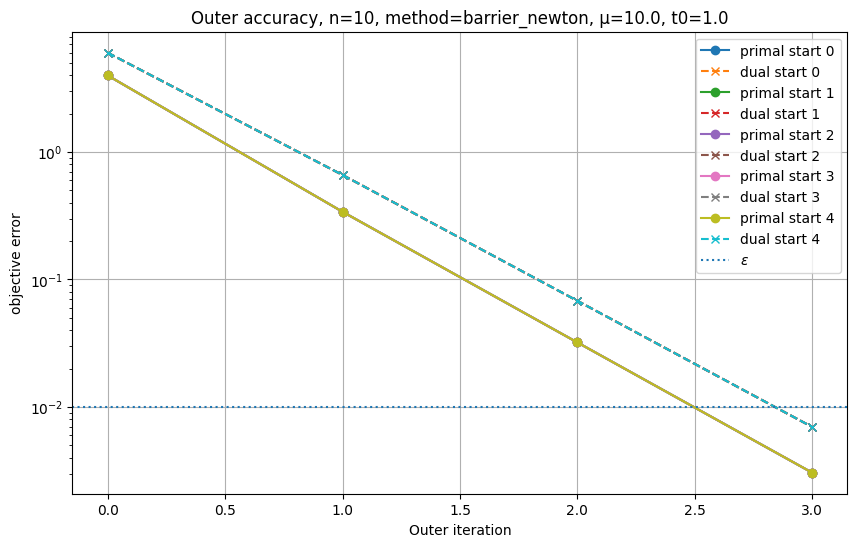

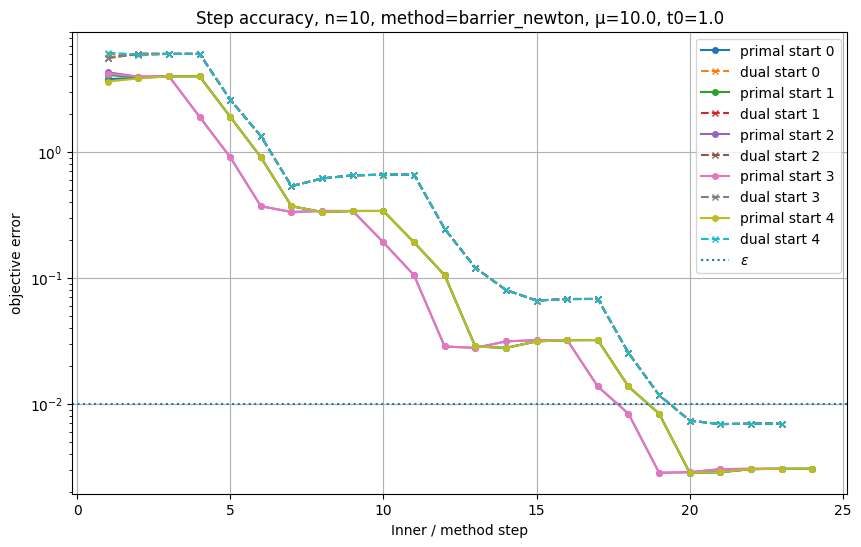

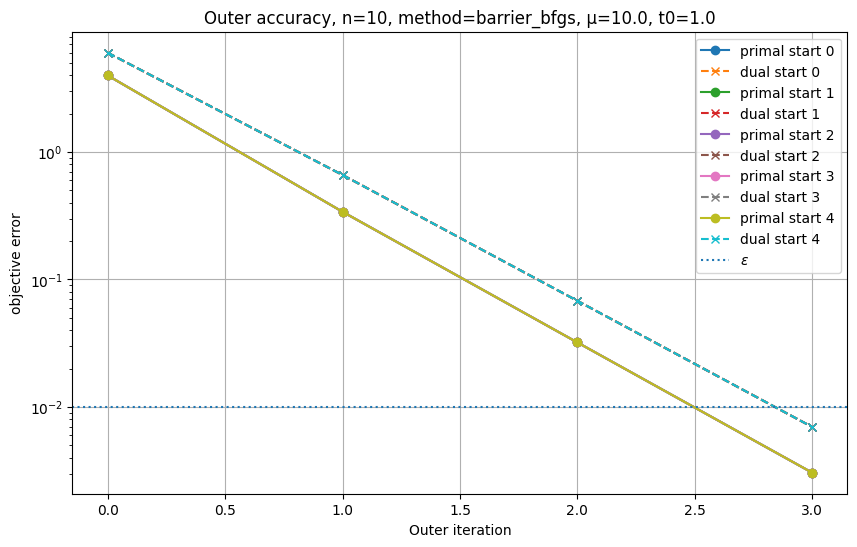

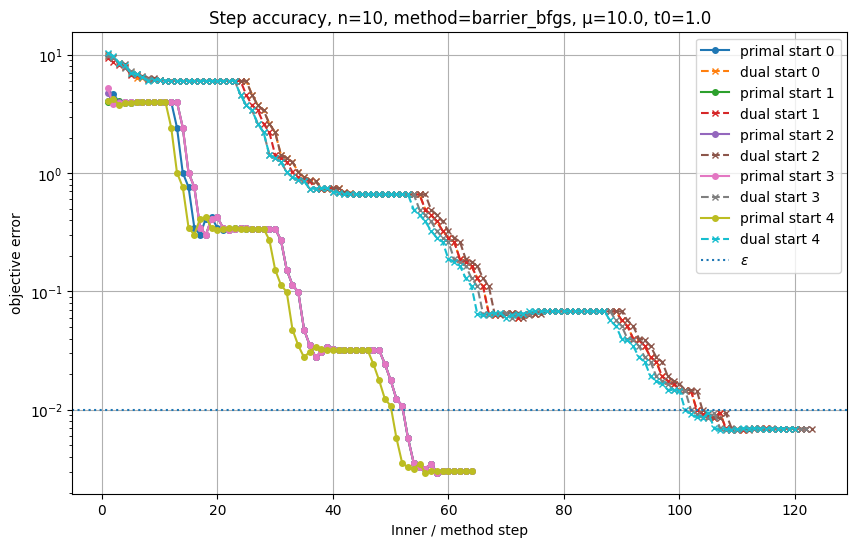

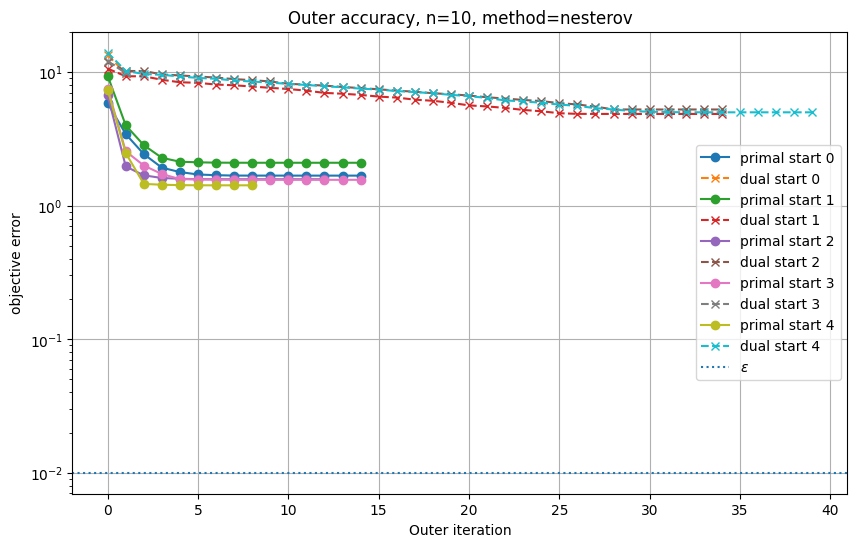

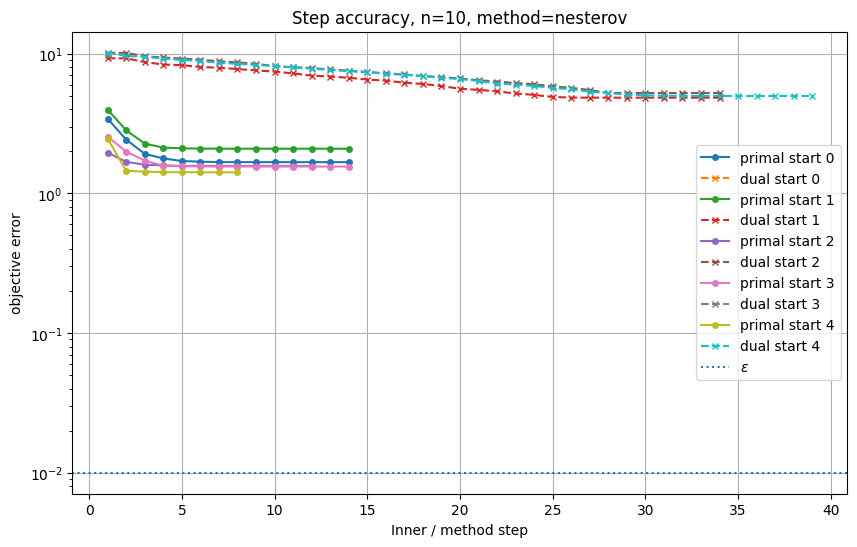

,method,n,primal_time,dual_time,primal_iters,dual_iters,primal_inner_steps,dual_inner_steps,primal_final_error,dual_final_error,primal_success,dual_success
0,barrier_bfgs,10,0.016471,0.039039,4.00,4.00,60.48,117.04,0.003031,0.006969,1.0,1.0
1,barrier_bfgs,20,0.026690,-0.002657,4.00,43.00,99.08,196.36,0.006982,0.010116,1.0,0.6
2,barrier_bfgs,30,0.033147,0.100963,4.60,100.00,123.84,270.64,0.007191,0.016485,1.0,0.0
3,barrier_bfgs,40,0.053764,0.126745,81.00,100.00,144.20,326.08,0.011831,0.036869,0.2,0.0
4,barrier_bfgs,50,0.073496,0.157069,81.00,100.00,172.12,337.20,0.014314,0.060916,0.2,0.0
5,barrier_bfgs,60,0.089859,0.160751,100.00,100.00,199.00,328.76,0.015626,0.097178,0.0,0.0
6,barrier_bfgs,70,0.108565,0.171420,100.00,100.00,236.96,343.36,0.021272,0.113442,0.0,0.0
7,barrier_bfgs,80,0.079101,0.183342,100.00,100.00,250.12,335.04,0.018624,0.196815,0.0,0.0
8,barrier_bfgs,90,0.153939,0.266713,100.00,100.00,279.52,343.76,0.025442,0.228048,0.0,0.0
9,barrier_bfgs,100,0.178018,0.310340,100.00,100.00,292.20,321.76,0.032533,0.341132,0.0,0.0


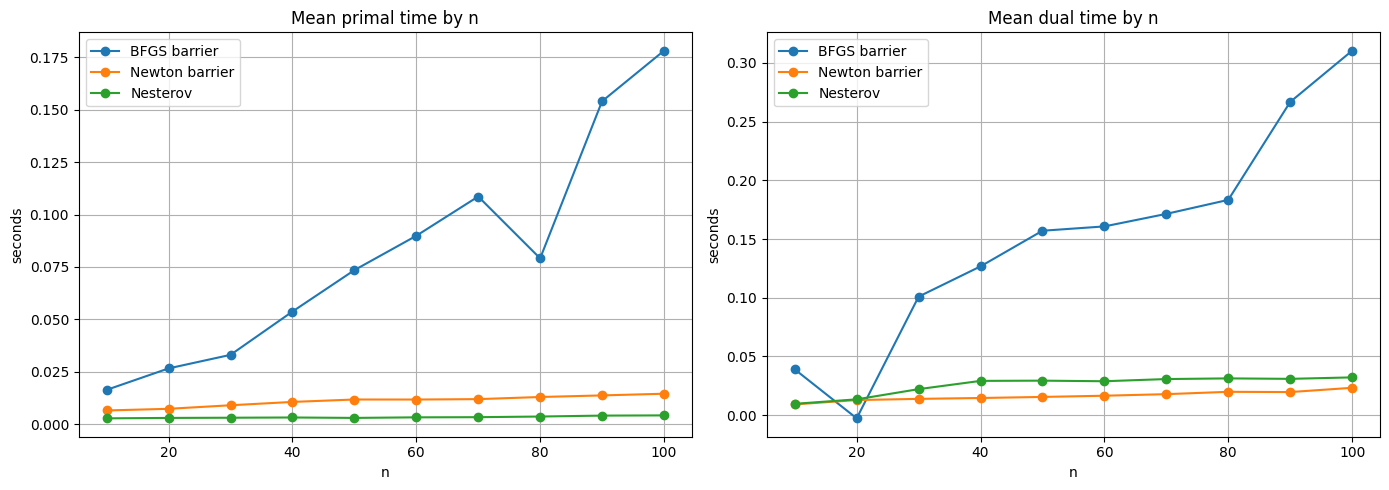

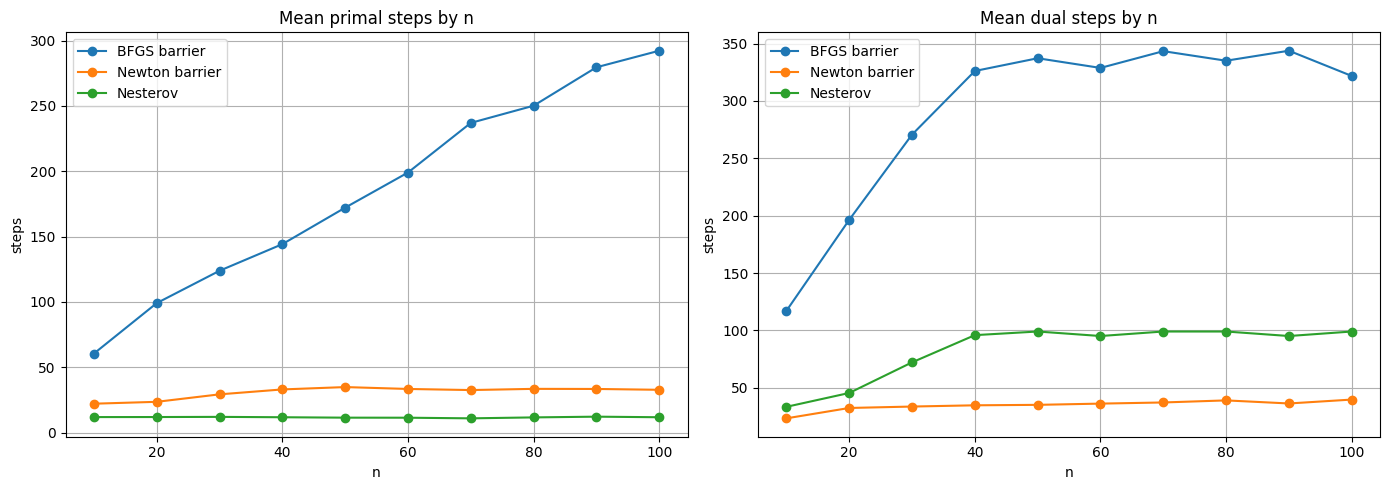

,method,primal_time,dual_time,primal_inner_steps,dual_inner_steps,primal_final_error,dual_final_error,primal_success,dual_success
0,barrier_bfgs,0.081305,0.151373,185.752,292.000,0.015685,0.110797,0.34,0.16
1,barrier_newton,0.011128,0.016379,30.844,34.728,0.002996,0.004261,1.00,1.00
2,nesterov,0.003475,0.025835,11.696,83.292,23.577093,28.969617,0.00,0.00


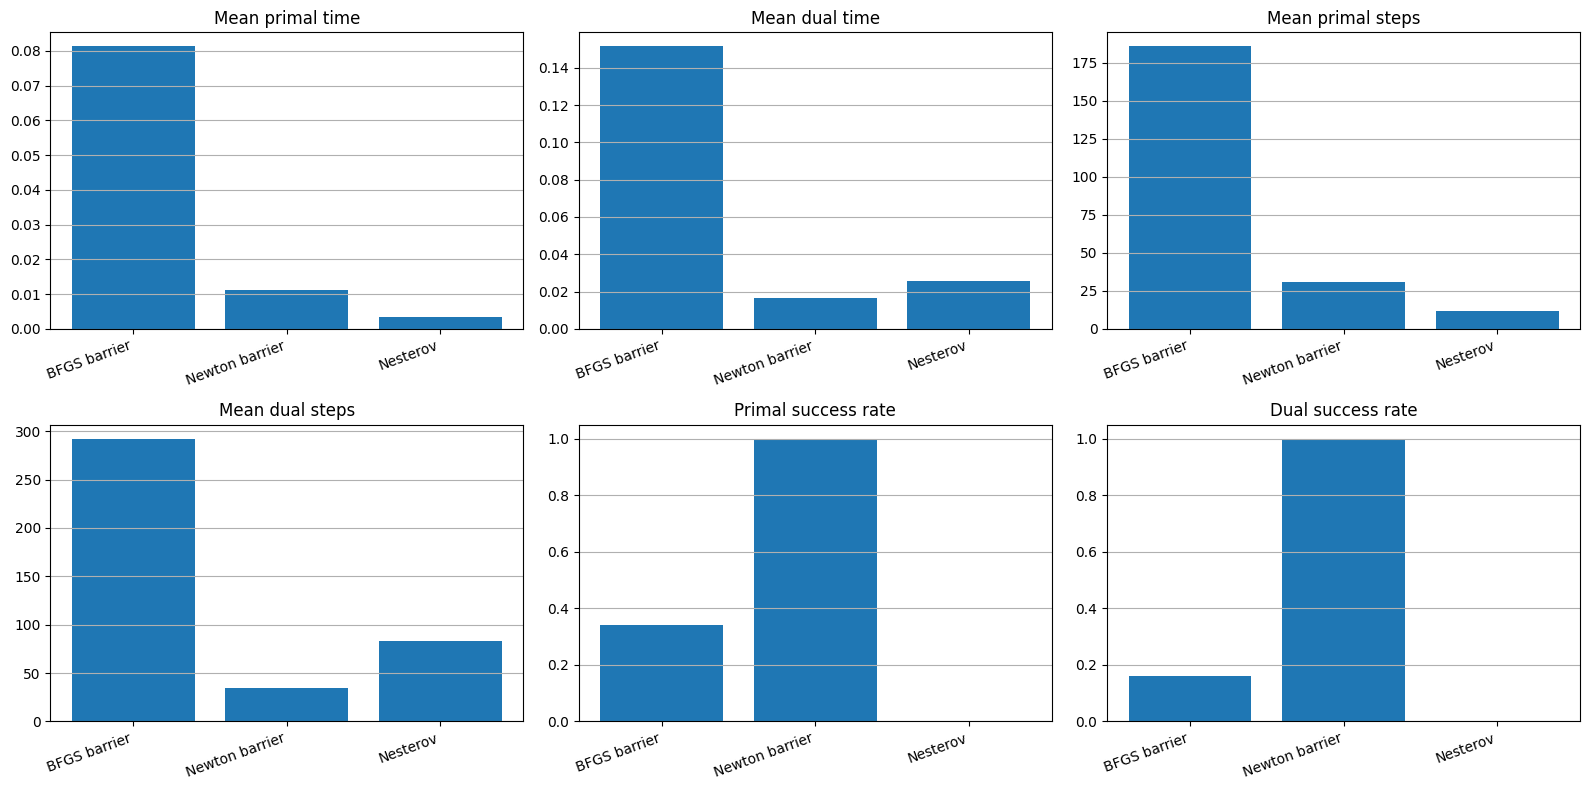

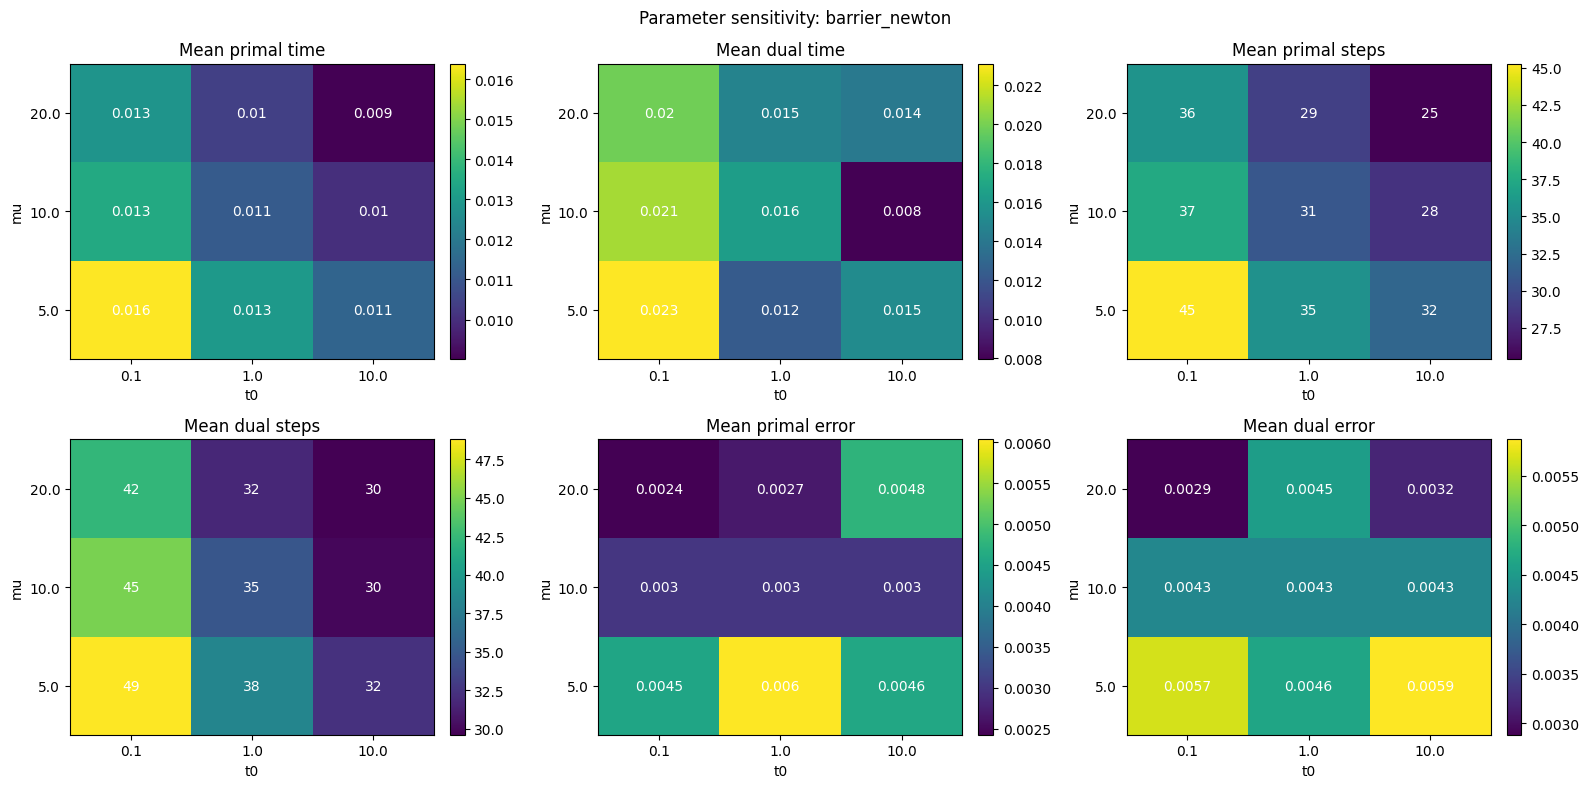

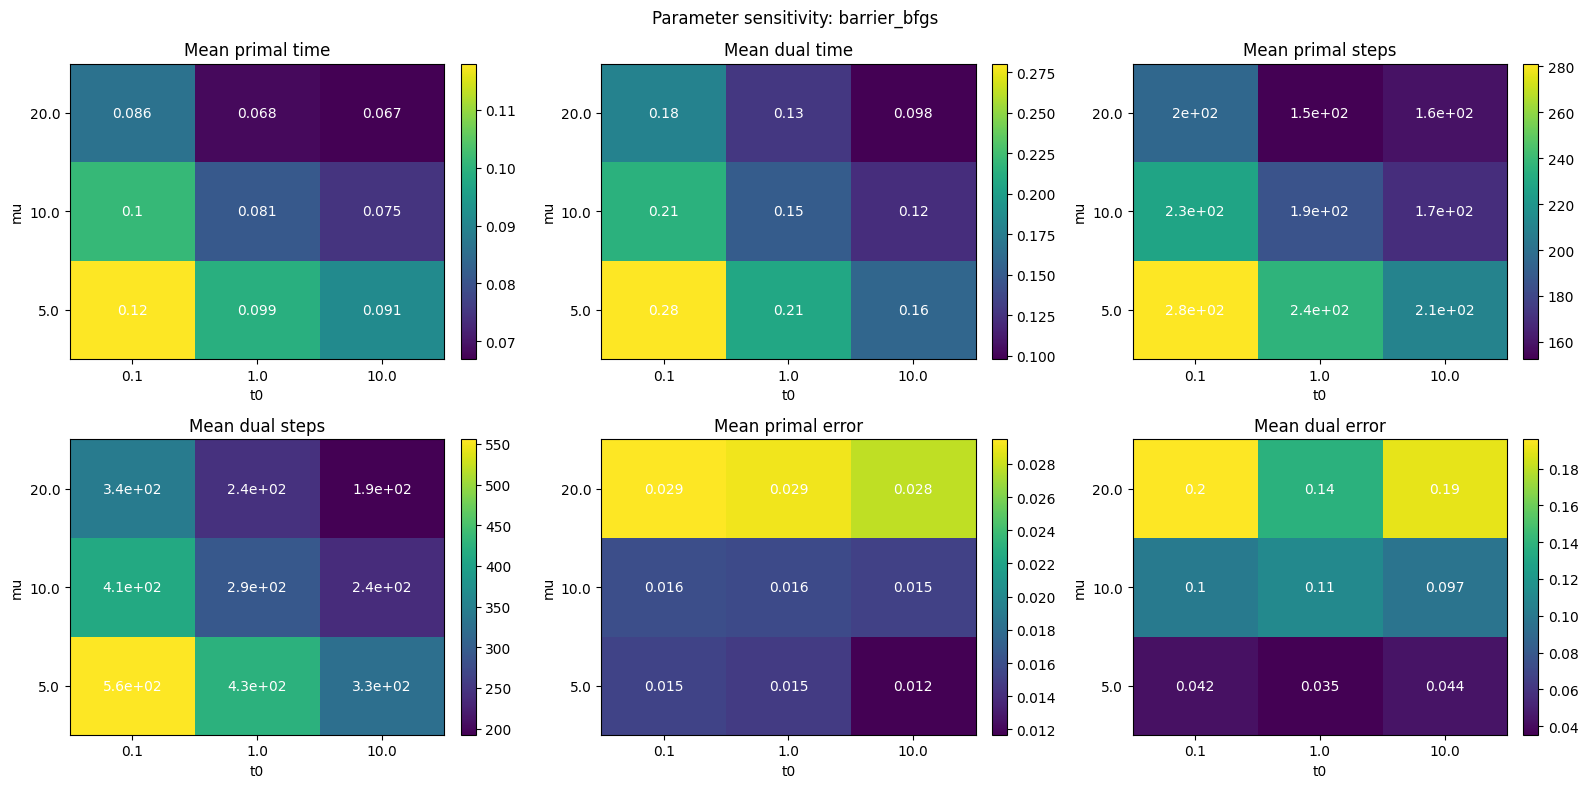

In [40]:
# (a) Accuracy for one n=10 test problem and several starts.
plot_accuracy_outer_for_n10(df_all, "barrier_newton", mu=10.0, t0=1.0)
plot_accuracy_steps_for_n10(df_all, "barrier_newton", mu=10.0, t0=1.0)

plot_accuracy_outer_for_n10(df_all, "barrier_bfgs", mu=10.0, t0=1.0)
plot_accuracy_steps_for_n10(df_all, "barrier_bfgs", mu=10.0, t0=1.0)

plot_accuracy_outer_for_n10(df_all, "nesterov")
plot_accuracy_steps_for_n10(df_all, "nesterov")

# (b) Mean time and mean number of iterations/steps for each n.
display(baseline_by_n)
plot_mean_time_by_n(baseline_by_n)
plot_mean_steps_by_n(baseline_by_n)

# (c) Comparison between two barrier versions and Nesterov baseline.
display(comparison)
plot_method_comparison_bar(comparison)

# Parameter sensitivity for barrier methods only.
plot_parameter_heatmaps(df_all, "barrier_newton")
plot_parameter_heatmaps(df_all, "barrier_bfgs")
